# Notebook 01 — EDA e Limpeza de Dados

Este notebook realiza o carregamento, limpeza e análise exploratória dos dados de bisnagas.

**Output:** `../data/data_cleaned.parquet`

## Bibliotecas

In [ ]:
import pandas as pd
print(f"Versão Pandas: {pd.__version__}")

Versão Pandas: 3.0.1


In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Carregando Dados

In [6]:
df = pd.read_csv(
    '../data/df_clusters_tcc.csv',
    sep=';',
    decimal=','
)

display(df.head())

,cod_pa,des_material,qt_altura_material,qt_comprimento_material,qt_peso_bruto,qt_volume_material,kde_qt_altura_material,kde_qt_largura_material,kde_qt_comprimento_material,kde_qt_peso_bruto,...,selagem_RETA_REC,selagem_TRANS,selagem_TRANS-REC,selagem_TRANS_LIS,kde_hibrido_qt_comprimento_material,kde_hibrido_qt_largura_material,diametro_material,kde_diametro_material,cluster_av2_sem_kde,cluster_gmm_av2_sem_kde
0,12504,CAPRICHO LOC HID DES CPO 200g,184.0,77.0,225.178,0.641,6,1,2,6,...,0,0,0,0,6,5,50.0,5,20,4
1,11881,ACQ FRESCA LOC HID 200g,182.0,80.0,227.014,0.641,6,1,2,6,...,0,0,0,0,6,5,50.0,5,20,4
2,10728,BOT MEN SHAMPOO ANTI-QUEDA 200ml,188.0,67.0,256.000,0.655,6,1,1,7,...,0,0,0,0,4,5,50.0,5,20,4
3,59147,LILY ESF HID CPO ACETINADO 200g,205.0,80.0,230.596,787.200,7,1,2,6,...,0,0,0,0,6,5,50.0,5,16,10
4,11790,VITACT PREENCHEDOR RUGAS 20g,147.0,30.0,37.050,182.700,5,1,1,0,...,0,0,0,0,1,4,19.0,0,9,9


### Cópia do DataFrame

In [7]:
df_bis = df.copy()

In [8]:
df_bis.columns

Index(['cod_pa', 'des_material', 'qt_altura_material',
       'qt_comprimento_material', 'qt_peso_bruto', 'qt_volume_material',
       'kde_qt_altura_material', 'kde_qt_largura_material',
       'kde_qt_comprimento_material', 'kde_qt_peso_bruto', 'selagem_BOOM',
       'selagem_MLUA', 'selagem_RETA', 'selagem_RETA_REC', 'selagem_TRANS',
       'selagem_TRANS-REC', 'selagem_TRANS_LIS',
       'kde_hibrido_qt_comprimento_material',
       'kde_hibrido_qt_largura_material', 'diametro_material',
       'kde_diametro_material', 'cluster_av2_sem_kde',
       'cluster_gmm_av2_sem_kde'],
      dtype='str')

### Remoção de colunas desnecessárias (KDE e clusters antigos)

In [9]:
excluir = ['kde_qt_altura_material','kde_qt_largura_material','kde_qt_comprimento_material',
       'kde_qt_comprimento_material', 'kde_qt_peso_bruto','kde_hibrido_qt_comprimento_material','kde_hibrido_qt_largura_material''kde_diametro_material', 'cluster_av2_sem_kde',
       'cluster_gmm_av2_sem_kde','kde_hibrido_qt_largura_material','kde_diametro_material']

df_bis.drop(columns=excluir, inplace= True, errors='ignore')
print(df_bis.columns.tolist())

['cod_pa', 'des_material', 'qt_altura_material', 'qt_comprimento_material', 'qt_peso_bruto', 'qt_volume_material', 'selagem_BOOM', 'selagem_MLUA', 'selagem_RETA', 'selagem_RETA_REC', 'selagem_TRANS', 'selagem_TRANS-REC', 'selagem_TRANS_LIS', 'diametro_material']


## EDA — Análise Exploratória

In [10]:
def resum_df(df_bis):
    
    print(f"O DataFrame tem {df_bis.shape[0]} linhas e {df_bis.shape[1]} colunas.\n")
    
    tabela_resumo = pd.DataFrame({
        'Valores_Unicos': df_bis.nunique(),
        'Valores_Nulos': df_bis.isna().sum(),
        'Percentual_Nulos': (df_bis.isna().sum() / len(df_bis) * 100).round(2),
        'Tipo_de_Dado': df_bis.dtypes
    })
    
    display(tabela_resumo)

resum_df(df_bis)

O DataFrame tem 2216 linhas e 14 colunas.



,Valores_Unicos,Valores_Nulos,Percentual_Nulos,Tipo_de_Dado
cod_pa,2216,0,0.0,int64
des_material,2210,0,0.0,str
qt_altura_material,184,0,0.0,float64
qt_comprimento_material,96,0,0.0,float64
qt_peso_bruto,1253,0,0.0,float64
qt_volume_material,650,0,0.0,float64
selagem_BOOM,2,0,0.0,int64
selagem_MLUA,2,0,0.0,int64
selagem_RETA,2,0,0.0,int64
selagem_RETA_REC,2,0,0.0,int64


In [11]:
display(df_bis[['diametro_material',
                'qt_altura_material',
                'qt_comprimento_material',
                'qt_peso_bruto']].describe())

,diametro_material,qt_altura_material,qt_comprimento_material,qt_peso_bruto
count,2216.000000,2216.000000,2216.000000,2216.000000
mean,42.408394,153.533511,55.388439,152.949322
std,8.593478,36.723927,23.665383,79.118607
min,19.000000,0.000000,0.000000,12.000000
25%,35.000000,127.000000,43.000000,81.467500
50%,40.000000,155.000000,50.000000,142.950000
75%,50.000000,180.000000,61.625000,225.262000
max,50.000000,245.000000,215.000000,320.000000


### Tratamento de valores 0

In [12]:
col_num= ['qt_altura_material','qt_comprimento_material']

In [13]:
for col in col_num:
    count_zero = (df[col]==0).sum()
    if count_zero>0: 
        print(f" A coluna {col} possui {count_zero} valores iguais a zero ")

 A coluna qt_altura_material possui 2 valores iguais a zero 
 A coluna qt_comprimento_material possui 2 valores iguais a zero 


In [14]:
df_bis = df_bis[(df_bis['qt_altura_material'] > 0) & (df_bis['qt_comprimento_material'] > 0)]

In [15]:
(df_bis[['qt_altura_material','qt_comprimento_material']].min())

qt_altura_material         18.0
qt_comprimento_material    18.6
dtype: float64

### Análise do perfil e distribuição das variáveis

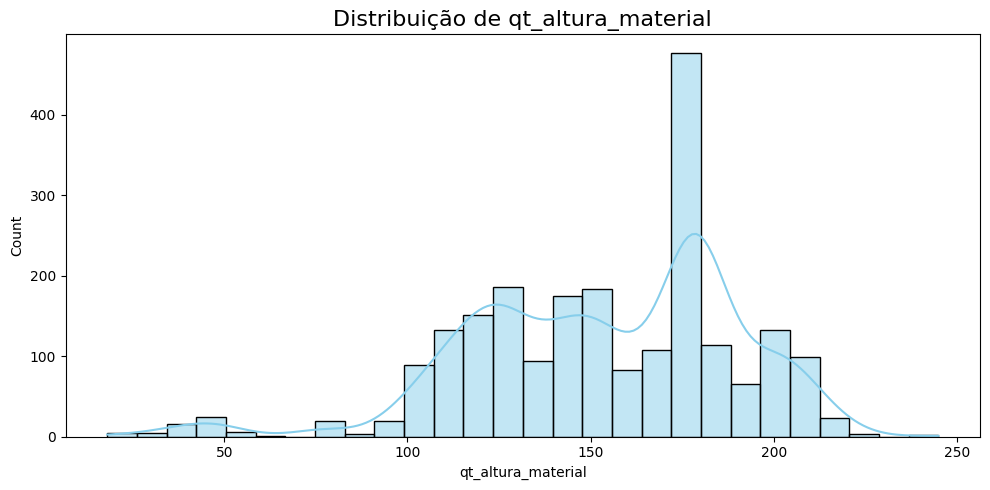

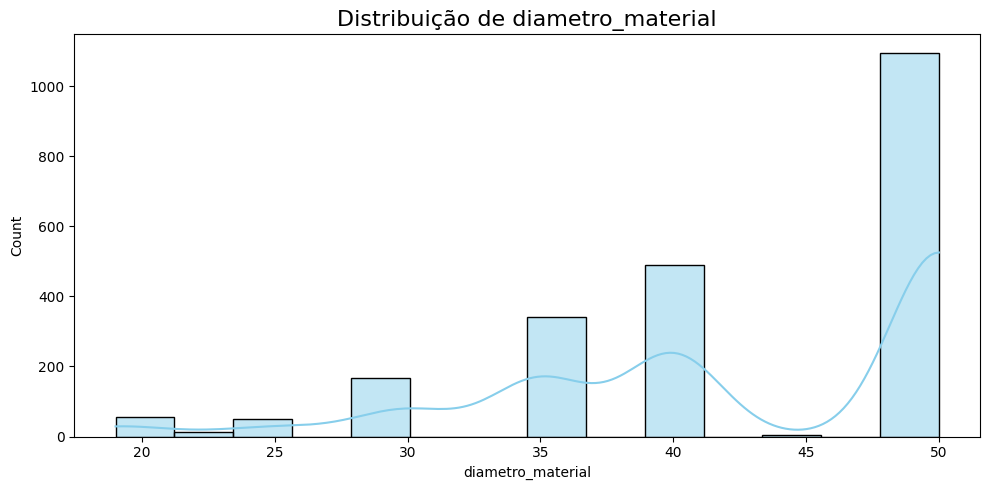

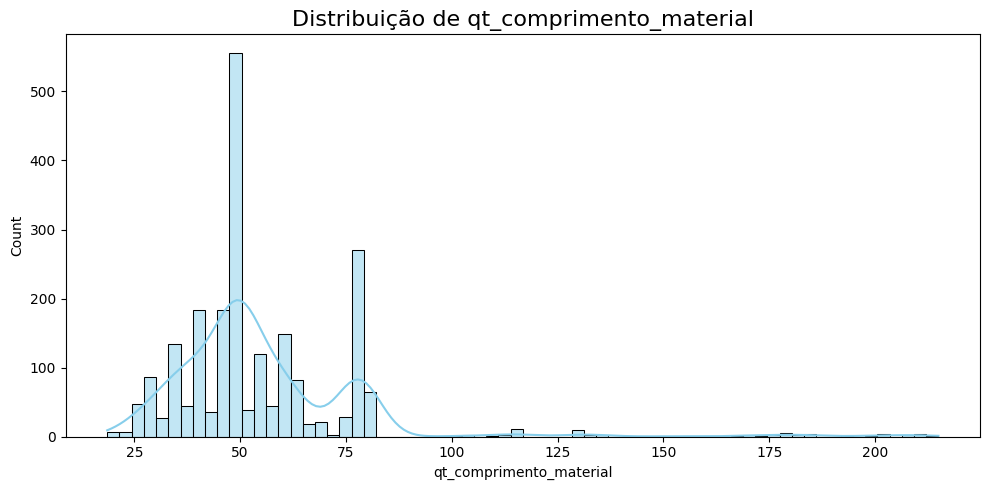

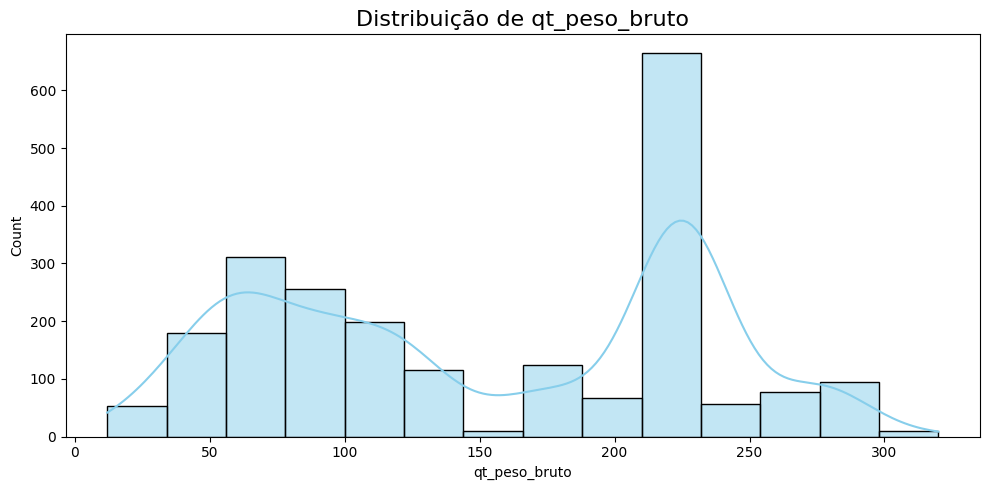

In [16]:
colunas_numericas = [
      'qt_altura_material',
    'diametro_material',
    'qt_comprimento_material',
    'qt_peso_bruto' 
]
for coluna in colunas_numericas:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df_bis, x=coluna, kde=True , color='skyblue')
    plt.title(f'Distribuição de {coluna}', fontsize=16)
    plt.tight_layout()
    plt.show()

### Análise dos tipos de selagem

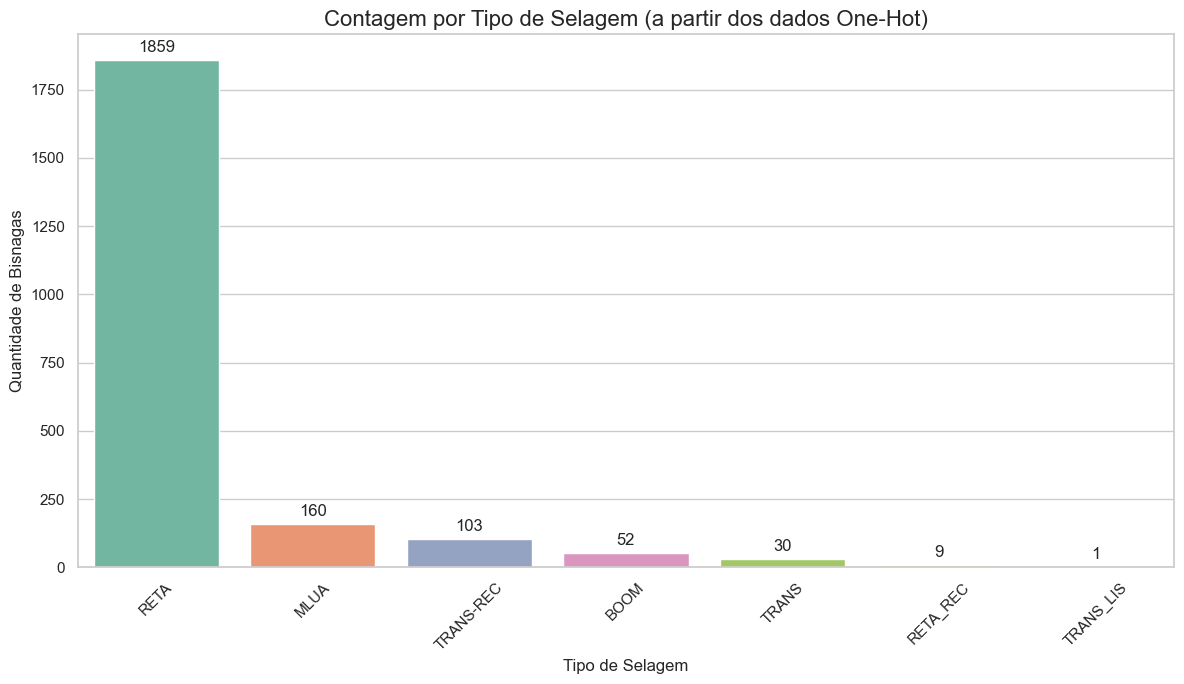

In [17]:
#Preparação dos dados 
colunas_de_selagem_ohe = [col for col in df_bis.columns if col.startswith('selagem_')]
contagens_de_selagem = df_bis[colunas_de_selagem_ohe].sum()
contagens_df = contagens_de_selagem.reset_index()
contagens_df.columns = ['Tipo_de_Selagem', 'Contagem']
contagens_df['Tipo_de_Selagem'] = contagens_df['Tipo_de_Selagem'].str.replace('selagem_', '')
contagens_df = contagens_df.sort_values(by='Contagem', ascending=False)


#gráfico de barras
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=contagens_df,
    x='Tipo_de_Selagem',
    y='Contagem',
    palette='Set2'
)



for p in ax.patches:
    
    ax.annotate(f'{int(p.get_height())}',        
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center',       
                xytext=(0, 9),                   
                textcoords='offset points')


plt.title('Contagem por Tipo de Selagem (a partir dos dados One-Hot)', fontsize=16)
plt.xlabel('Tipo de Selagem', fontsize=12)
plt.ylabel('Quantidade de Bisnagas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Agrupamento TRANS_LIS → TRANS

Agrupei o tipo de selagem TRANS_LIS ao tipo de selagem TRANS devido só ter somente um sku com essa característica

In [18]:
if 'selagem_TRANS_LIS' in df_bis.columns and 'selagem_TRANS' in df_bis.columns:
   
    condicao_trans_lis = df_bis['selagem_TRANS_LIS'] == 1
    
    df_bis.loc[condicao_trans_lis, 'selagem_TRANS'] = 1
    
    df_bis.drop(columns=['selagem_TRANS_LIS'], inplace=True)

    
else:
    print("As colunas necessárias para o agrupamento não foram encontradas.")

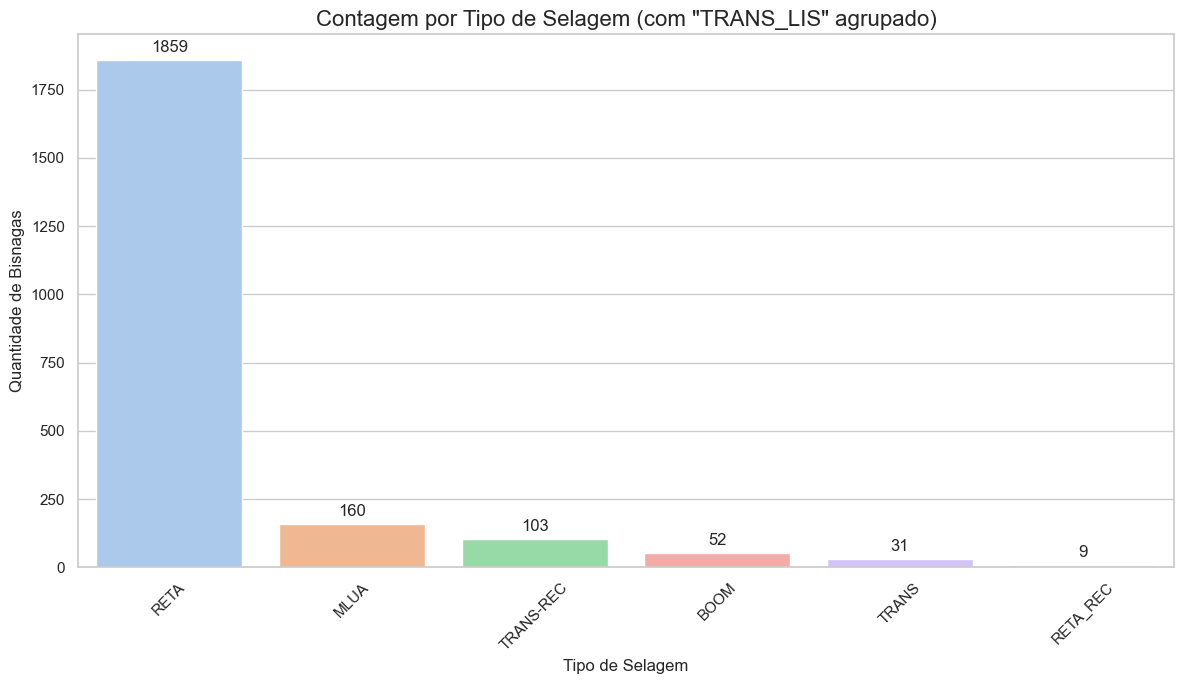

In [19]:
colunas_de_selagem_ohe = [col for col in df_bis.columns if col.startswith('selagem_')]
contagens_de_selagem = df_bis[colunas_de_selagem_ohe].sum()
contagens_df = contagens_de_selagem.reset_index()
contagens_df.columns = ['Tipo_de_Selagem', 'Contagem']
contagens_df['Tipo_de_Selagem'] = contagens_df['Tipo_de_Selagem'].str.replace('selagem_', '')
contagens_df = contagens_df.sort_values(by='Contagem', ascending=False)


plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=contagens_df,
    x='Tipo_de_Selagem',
    y='Contagem',
    palette='pastel',
    hue='Tipo_de_Selagem', 
    legend=False         
)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Contagem por Tipo de Selagem (com "TRANS_LIS" agrupado)', fontsize=16)
plt.xlabel('Tipo de Selagem', fontsize=12)
plt.ylabel('Quantidade de Bisnagas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Salvamento dos dados limpos

In [20]:
df_bis.to_parquet('../data/data_cleaned.parquet', index=False)
print(f"✓ Dados limpos salvos em '../data/data_cleaned.parquet'")
print(f"  Shape: {df_bis.shape}")
print(f"  Colunas: {df_bis.columns.tolist()}")

✓ Dados limpos salvos em '../data/data_cleaned.parquet'
  Shape: (2214, 13)
  Colunas: ['cod_pa', 'des_material', 'qt_altura_material', 'qt_comprimento_material', 'qt_peso_bruto', 'qt_volume_material', 'selagem_BOOM', 'selagem_MLUA', 'selagem_RETA', 'selagem_RETA_REC', 'selagem_TRANS', 'selagem_TRANS-REC', 'diametro_material']
